In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import matrix
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [137]:
data=pd.read_csv("global_cancer_patients_2015_2024.csv")

In [138]:
data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54


In [73]:
data.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
       'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years',
       'Target_Severity_Score'],
      dtype='object')

In [74]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [75]:
data.describe()

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.421540,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,52467.298239,5.006462,4.951207
std,20.224451,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,27363.229379,2.883335,1.199677
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.225000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76232.720000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


In [76]:
data.duplicated().sum()

np.int64(0)

In [77]:
data.isnull().sum()

Patient_ID               0
Age                      0
Gender                   0
Country_Region           0
Year                     0
Genetic_Risk             0
Air_Pollution            0
Alcohol_Use              0
Smoking                  0
Obesity_Level            0
Cancer_Type              0
Cancer_Stage             0
Treatment_Cost_USD       0
Survival_Years           0
Target_Severity_Score    0
dtype: int64

#Descriptive Analysis

In [78]:
data["Age"]

0        71
1        34
2        80
3        40
4        43
         ..
49995    80
49996    40
49997    74
49998    21
49999    22
Name: Age, Length: 50000, dtype: int64

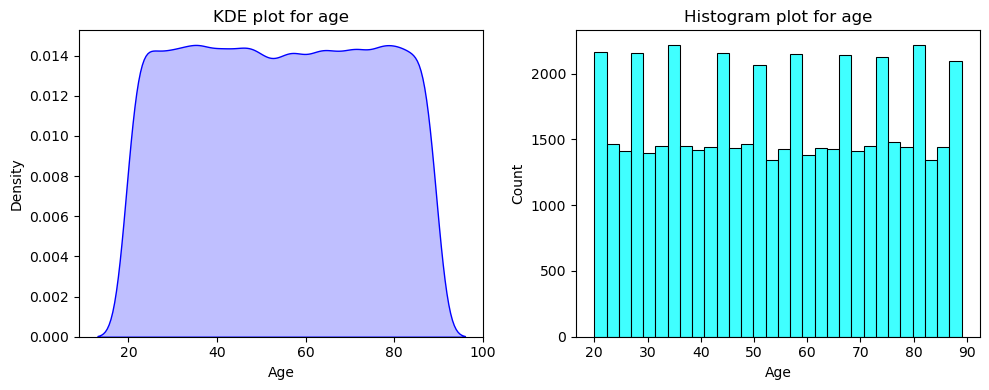

In [79]:
#Age column
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(data["Age"],fill=True,color="blue")
plt.ticklabel_format(axis='y', style='plain')
plt.title("KDE plot for age")

plt.subplot(1,2,2)
sns.histplot(data["Age"],bins=30,kde=False,color="cyan")
plt.title("Histogram plot for age")



plt.tight_layout()
plt.show()

In [80]:
data["Age"].describe()

count    50000.000000
mean        54.421540
std         20.224451
min         20.000000
25%         37.000000
50%         54.000000
75%         72.000000
max         89.000000
Name: Age, dtype: float64

In [81]:
#Gender column
data["Gender"].value_counts()

Gender
Male      16796
Female    16709
Other     16495
Name: count, dtype: int64

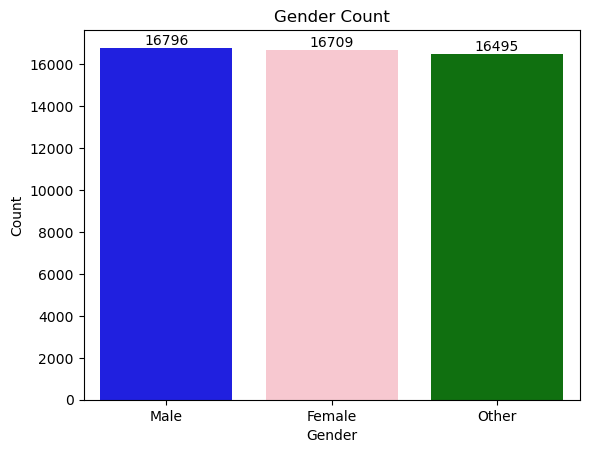

In [82]:
sns.barplot(
    x=data["Gender"].value_counts().index,
    y=data["Gender"].value_counts().values,
    palette=["blue","pink","green"]
)

for i ,v in enumerate(data["Gender"].value_counts()):
    plt.text(i,v,str(v),ha="center",va="bottom")

plt.title("Gender Count")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [83]:
#Countries column
country_count=data["Country_Region"].value_counts()

In [84]:
country_count

Country_Region
Australia    5092
UK           5060
USA          5060
India        5040
Germany      5024
Russia       5017
Brazil       5004
Pakistan     4926
China        4913
Canada       4864
Name: count, dtype: int64

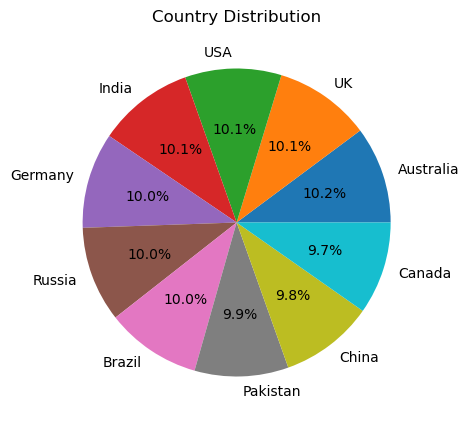

In [85]:
plt.figure(figsize=(5,5))
plt.pie(x=country_count.values,
        labels=country_count.index,
        autopct="%1.1f%%"
)
plt.title("Country Distribution")
plt.show()

In [86]:
#Cancer column
data["Cancer_Type"].value_counts()

Cancer_Type
Colon       6376
Prostate    6308
Leukemia    6266
Liver       6249
Skin        6231
Cervical    6222
Breast      6189
Lung        6159
Name: count, dtype: int64

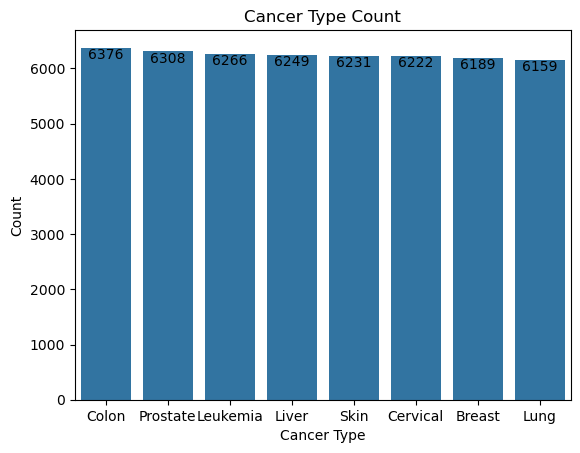

In [87]:
sns.barplot(x=data["Cancer_Type"].value_counts().index,
            y=data["Cancer_Type"].value_counts().values,
           )

for i,v in enumerate(data["Cancer_Type"].value_counts()):
    plt.text(i,v,str(v),ha="center",va="top")

plt.title("Cancer Type Count")
plt.xlabel("Cancer Type")
plt.ylabel("Count")
plt.show()

In [88]:
# Cancer Stage
data["Cancer_Stage"].value_counts()

Cancer_Stage
Stage II     10124
Stage I      10046
Stage III    10008
Stage IV      9933
Stage 0       9889
Name: count, dtype: int64

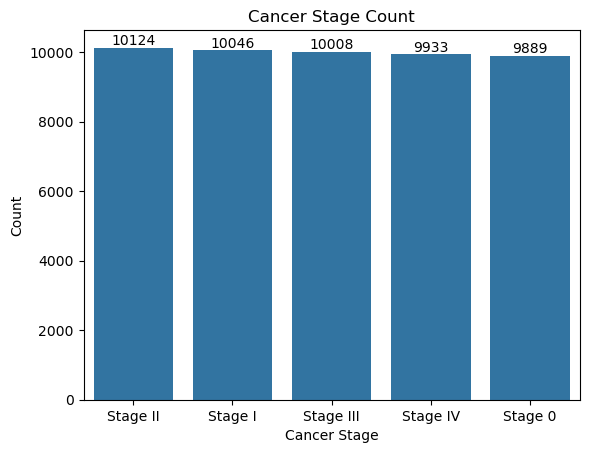

In [89]:
sns.barplot(x=data["Cancer_Stage"].value_counts().index,
            y=data["Cancer_Stage"].value_counts().values,
           )

for i,v in enumerate(data["Cancer_Stage"].value_counts()):
    plt.text(i,v,str(v),ha="center",va="bottom")

plt.title("Cancer Stage Count")
plt.xlabel("Cancer Stage")
plt.ylabel("Count")
plt.show()

In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [91]:
#Cancer Treatment Cost
data["Treatment_Cost_USD"]

0        62913.44
1        12573.41
2         6984.33
3        67446.25
4        77977.12
           ...   
49995    71463.70
49996    49619.66
49997     5338.25
49998    45100.47
49999    64023.82
Name: Treatment_Cost_USD, Length: 50000, dtype: float64

In [92]:
USD_TO_INR = 89

data["Treatment_Cost_INR"] = data["Treatment_Cost_USD"] * USD_TO_INR


In [93]:
data["Treatment_Cost_INR"]

0        5599296.16
1        1119033.49
2         621605.37
3        6002716.25
4        6939963.68
            ...    
49995    6360269.30
49996    4416149.74
49997     475104.25
49998    4013941.83
49999    5698119.98
Name: Treatment_Cost_INR, Length: 50000, dtype: float64

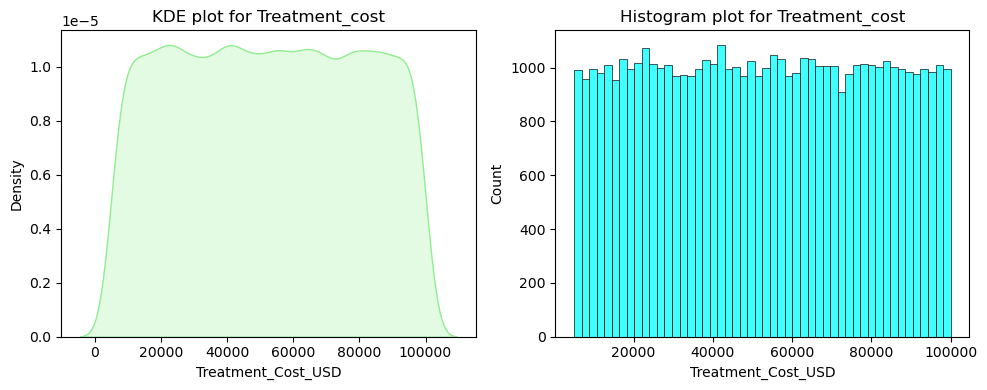

In [94]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(data["Treatment_Cost_USD"],fill=True,color="lightgreen")
plt.title("KDE plot for Treatment_cost")

plt.subplot(1,2,2)
sns.histplot(data["Treatment_Cost_USD"],bins=50,kde=False,color="cyan")
plt.title("Histogram plot for Treatment_cost")

plt.tight_layout()
plt.show()

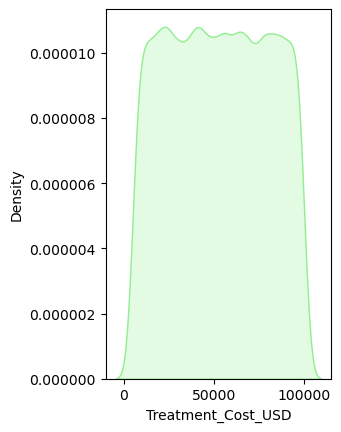

In [95]:
plt.subplot(1,2,1)
sns.kdeplot(data["Treatment_Cost_USD"], fill=True, color="lightgreen")
plt.ticklabel_format(axis='y', style='plain')


In [96]:
data["Treatment_Cost_USD"].describe()

count    50000.000000
mean     52467.298239
std      27363.229379
min       5000.050000
25%      28686.225000
50%      52474.310000
75%      76232.720000
max      99999.840000
Name: Treatment_Cost_USD, dtype: float64

In [97]:
#ANALYZING RISK FACTOR
data.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
       'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years',
       'Target_Severity_Score', 'Treatment_Cost_INR'],
      dtype='object')

In [98]:
column_of_interest=['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']

In [99]:
summary = data[column_of_interest].agg(["mean","std","min","max"])

In [100]:
summary

,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level
mean,5.001698,5.010126,5.010880,4.989826,4.991176
std,2.885773,2.888399,2.888769,2.881579,2.894504
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000


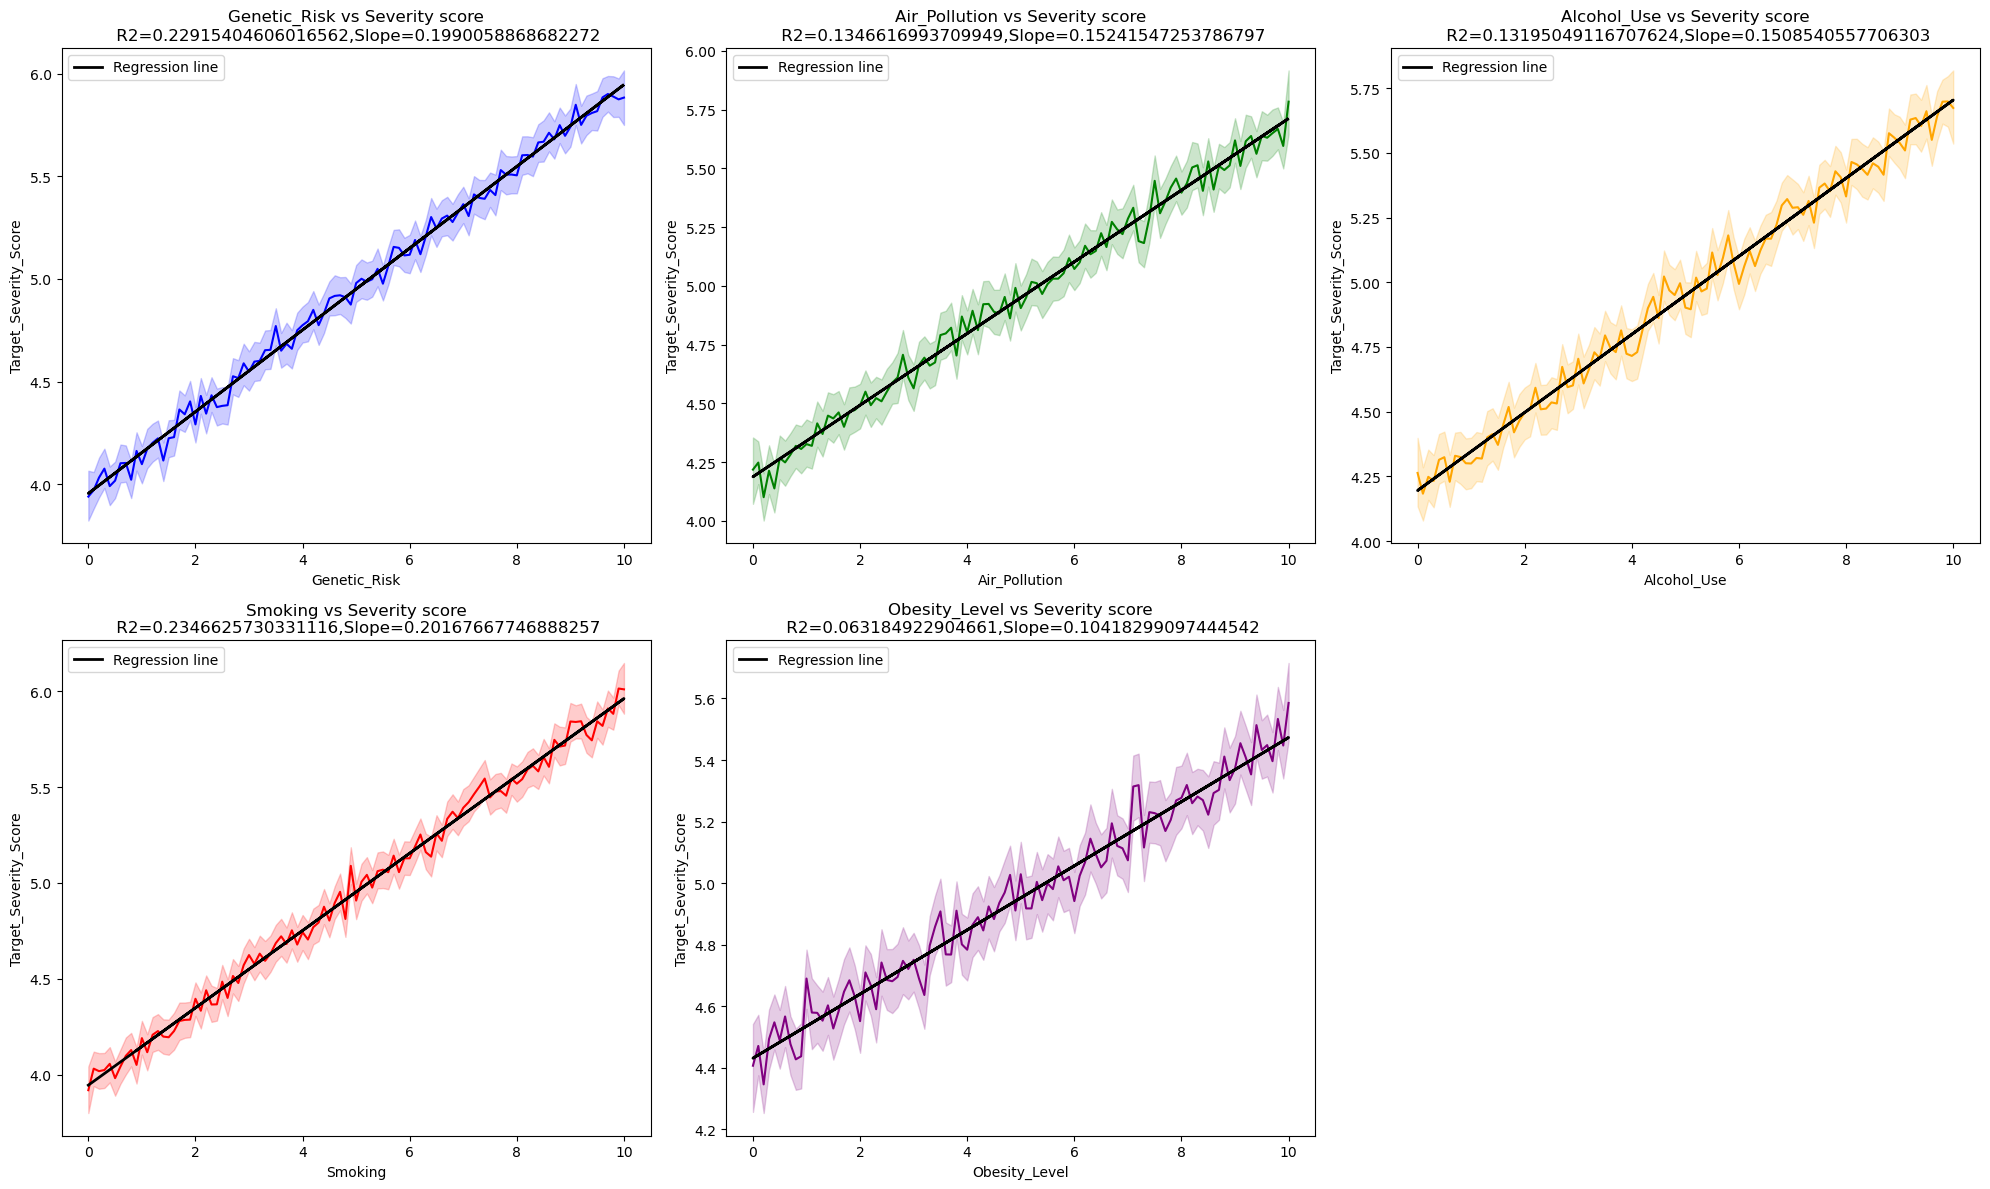

In [101]:
from scipy.stats import linregress
risk_factors=['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
titles= ['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
colors = ["blue","green","orange","red","purple"]

plt.figure(figsize=(20,12))
for i,(factor,title,color) in enumerate (zip(risk_factors,titles,colors),1):
    plt.subplot(2,3,i)
    x=data[factor]
    y=data["Target_Severity_Score"]
    slope,intercept,r_value,p_value,std_err=linregress(x,y)
    r_squared=r_value**2

    sns.lineplot(x=factor,y="Target_Severity_Score",data=data,color=color)
    plt.plot(x,x*slope+intercept, color="black",linewidth=2,label="Regression line")
    plt.title(f"{title} vs Severity score\n R2={r_squared},Slope={slope}")
    plt.xlabel(factor)
    plt.ylabel("Target_Severity_Score")
    plt.legend()

plt.tight_layout()
plt.show()

# Analyze the Propertion Of Early Stage diagnosis by cancer type

In [102]:
data["Cancer_Type"].unique()

array(['Lung', 'Leukemia', 'Breast', 'Colon', 'Skin', 'Cervical',
       'Prostate', 'Liver'], dtype=object)

In [103]:
stage_count=data[data["Cancer_Type"]=="Lung"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of lungs cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of lungs cancer diagnosed at stage 0 and stage 1:38.43156356551388


In [104]:
stage_count

Cancer_Stage
Stage II     1298
Stage IV     1286
Stage III    1208
Stage 0      1185
Stage I      1182
Name: count, dtype: int64

In [105]:
stage_count=data[data["Cancer_Type"]=="Leukemia"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Leukemia cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Leukemia cancer diagnosed at stage 0 and stage 1:39.53080114905841


In [106]:
stage_count=data[data["Cancer_Type"]=="Breast"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Breast cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Breast cancer diagnosed at stage 0 and stage 1:39.47325900791727


In [107]:
stage_count=data[data["Cancer_Type"]=="Skin"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Skin cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Skin cancer diagnosed at stage 0 and stage 1:40.41084898090194


In [108]:
stage_count=data[data["Cancer_Type"]=="Colon"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Colon cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Colon cancer diagnosed at stage 0 and stage 1:40.41718946047679


In [109]:
stage_count=data[data["Cancer_Type"]=="Cervical"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Cervical cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Cervical cancer diagnosed at stage 0 and stage 1:39.85856637737062


In [110]:
stage_count=data[data["Cancer_Type"]=="Prostate"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Prostate cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Prostate cancer diagnosed at stage 0 and stage 1:40.187064045656314


In [111]:
stage_count=data[data["Cancer_Type"]=="Liver"]["Cancer_Stage"].value_counts()
early_stage_sum = stage_count.get("Stage 0",0)+stage_count.get("Stage I",0)
total_sum=stage_count.sum()
proportion = (early_stage_sum/total_sum)*100
print(f"Propertion of Liver cancer diagnosed at stage 0 and stage 1:{proportion}")

Propertion of Liver cancer diagnosed at stage 0 and stage 1:40.614498319731155


# Identify key predictors of cancer severity and survival years

In [112]:
features = ["Age" ,'Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level' ]

targets=["Survival_Years","Target_Severity_Score"]

#calculate correlatins
pearson_corr = data[features+targets].corr(method="pearson")
spearman_corr = data[features+targets].corr(method="spearman")

#slice out only thr relationship with target variables
pearson_results = pearson_corr[targets]
spearman_results=spearman_corr[targets]

#combines both
correlation_df=pd.concat([pearson_results,spearman_results],axis=1,keys=["Pearson","Spearman"])
correlation_df

Pearson                             Spearman  \
                      Survival_Years Target_Severity_Score Survival_Years   
Age                        -0.000147             -0.001481      -0.000149   
Genetic_Risk                0.001708              0.478700       0.001684   
Air_Pollution               0.000893              0.366963       0.000841   
Alcohol_Use                -0.000527              0.363250      -0.000543   
Smoking                     0.001371              0.484420       0.001372   
Obesity_Level               0.009771              0.251366       0.009780   
Survival_Years              1.000000              0.004161       1.000000   
Target_Severity_Score       0.004161              1.000000       0.003431   

                                             
                      Target_Severity_Score  
Age                               -0.002076  
Genetic_Risk                       0.472193  
Air_Pollution                      0.357528  
Alcohol_Use                        0.354694  
Smoking                            0.477881  
Obesity_Level                      0.243152  
Survival_Years                     0.003431  
Target_Severity_Score              1.000000

In [113]:
data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score,Treatment_Cost_INR
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92,5599296.16
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65,1119033.49
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84,621605.37
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12,6002716.25
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62,6939963.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63,6360269.30
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03,4416149.74
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02,475104.25
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54,4013941.83


In [114]:
X

,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage
0,71,1,8,2021,6.4,2.8,9.5,0.9,8.7,5,3
1,34,1,3,2021,1.3,4.5,3.7,3.9,6.3,3,0
2,80,1,6,2023,7.4,7.9,2.4,4.7,0.1,0,2
3,40,1,8,2015,1.7,2.9,4.8,3.5,2.7,2,1
4,43,0,1,2017,5.1,2.8,2.3,6.7,0.5,7,3
...,...,...,...,...,...,...,...,...,...,...,...
49995,80,1,6,2023,2.3,7.5,2.8,3.8,2.9,3,0
49996,40,0,9,2018,6.4,3.5,2.9,9.0,9.8,2,1
49997,74,1,6,2015,6.2,1.6,8.7,4.7,4.0,0,0
49998,21,1,1,2018,4.0,6.5,7.6,8.6,8.1,4,4


In [119]:
# Random Forest for Target_serverity_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

# converting from categorical column to numerical column

categorical_col = ["Gender","Country_Region","Cancer_Type","Cancer_Stage"]
for col in categorical_col:
    le=LabelEncoder()
    data[col]=le.fit_transform(data[col])

# Preparing features and input
X=data.drop(columns=["Patient_ID","Treatment_Cost_USD","Survival_Years","Target_Severity_Score","Treatment_Cost_USD"])
y_serverity=data["Target_Severity_Score"]

# train_test_split
X_train_s,X_test_s,y_train_s,y_test_s=train_test_split(X,y_serverity,test_size=0.2,random_state=40)

model=RandomForestRegressor(n_estimators=200,max_depth=None,min_samples_split=2,min_samples_leaf=1,random_state=40)
model.fit(X_train_s,y_train_s)

train_r2_serverity=r2_score(y_train_s,model.predict(X_train_s))
test_r2_serverity=r2_score(y_test_s,model.predict(X_test_s))






In [120]:
print(train_r2_serverity)
print(test_r2_serverity)


0.9971504644134414
0.979687346778428


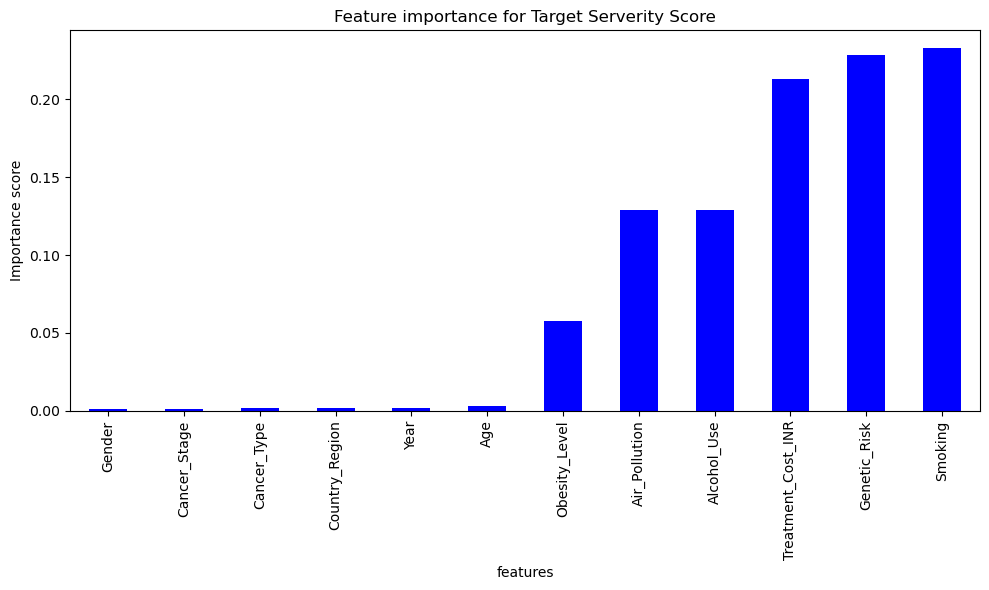

In [121]:
feature_importance_serverity = pd.Series(model.feature_importances_,index=X.columns,).sort_values(ascending=True)

# ploting important feature
plt.figure(figsize=(10,6))
feature_importance_serverity.plot(kind="bar",color="blue")
plt.title("Feature importance for Target Serverity Score")
plt.xlabel("features")
plt.ylabel("Importance score")
plt.tight_layout()
plt.show()

In [127]:
# Random Forest for Target_serverity_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

# converting from categorical column to numerical column

categorical_col = ["Gender","Country_Region","Cancer_Type","Cancer_Stage"]
for col in categorical_col:
    le=LabelEncoder()
    data[col]=le.fit_transform(data[col])

# Preparing features and input
X=data.drop(columns=["Patient_ID","Treatment_Cost_USD","Survival_Years","Target_Severity_Score","Treatment_Cost_INR"])
y_severity=data["Survival_Years"]

# train_test_split
X_train_s,X_test_s,y_train_s,y_test_s=train_test_split(X,y_severity,test_size=0.2,random_state=40)
param_grid={
    "n_estimators":[100,200],
    "max_depth":[5,10,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

model=RandomForestRegressor(random_state=40)
GSC=GridSearchCV(model,param_grid,cv=3,scoring="r2",n_jobs=-1)
GSC.fit(X_train_s,y_train_s)

best_rf_severity = GSC.best_estimator_

train_r2_severity=r2_score(y_train_s,best_rf_severity.predict(X_train_s))
test_r2_severity=r2_score(y_test_s,best_rf_severity.predict(X_test_s))






Exception ignored in: <function ResourceTracker.__del__ at 0x1077632e0>
Traceback (most recent call last):
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103b472e0>
Traceback (most recent call last):
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__

In [129]:
print(train_r2_severity)
print(test_r2_severity)


0.008998065861791305
-0.0003487352301705382


<Axes: ylabel='Count'>

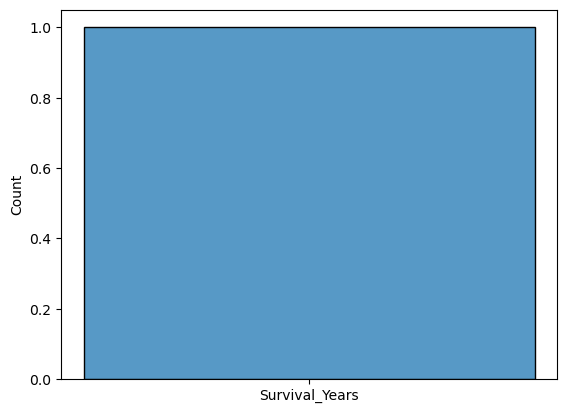

In [135]:
import seaborn as sns
sns.histplot(["Survival_Years"],kde=False)

In [134]:
data.corr(numeric_only=True)["Survival_Years"].sort_values(ascending=True)

Gender                  -0.007121
Cancer_Stage            -0.003014
Cancer_Type             -0.001717
Alcohol_Use             -0.000527
Treatment_Cost_USD      -0.000429
Treatment_Cost_INR      -0.000429
Age                     -0.000147
Year                     0.000018
Air_Pollution            0.000893
Smoking                  0.001371
Genetic_Risk             0.001708
Target_Severity_Score    0.004161
Country_Region           0.005121
Obesity_Level            0.009771
Survival_Years           1.000000
Name: Survival_Years, dtype: float64

In [136]:
df=data.copy()

In [139]:
data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54


In [140]:
data["Age_Group"]=pd.cut(data["Age"],bins=[0,30,45,60,75,100],labels=["0-30","31-45","46-60","61-75","76+"])

In [141]:
data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score,Age_Group
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92,61-75
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65,31-45
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84,76+
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12,31-45
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62,31-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63,76+
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03,31-45
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02,61-75
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54,0-30


In [147]:
data.groupby(["Country_Region","Age_Group","Gender"])["Treatment_Cost_USD"].mean().reset_index()

,Country_Region,Age_Group,Gender,Treatment_Cost_USD
0,Australia,0-30,Female,53287.701319
1,Australia,0-30,Male,52939.875035
2,Australia,0-30,Other,53776.208452
3,Australia,31-45,Female,51647.694000
4,Australia,31-45,Male,54212.453438
...,...,...,...,...
145,USA,61-75,Male,55381.892304
146,USA,61-75,Other,52070.474766
147,USA,76+,Female,51877.032768
148,USA,76+,Male,52445.346342


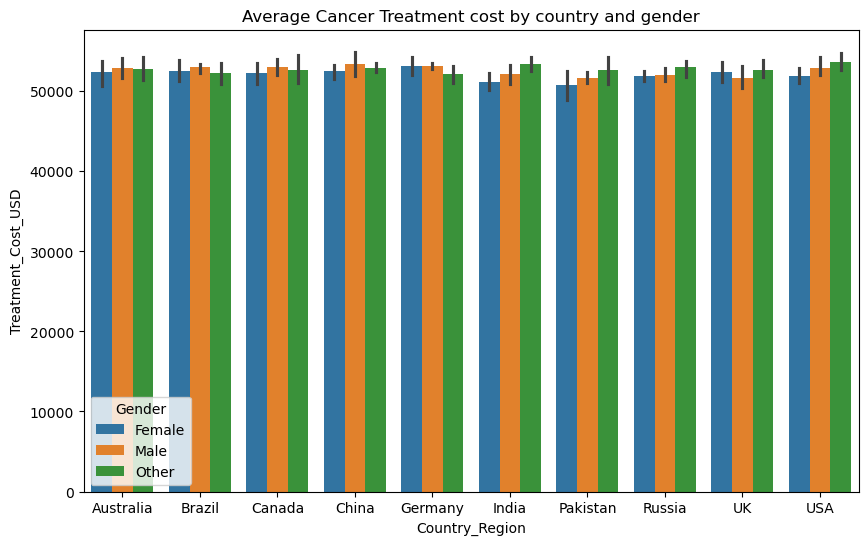

In [150]:
country_age_cost=data.groupby(["Country_Region","Age_Group","Gender"])["Treatment_Cost_USD"].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=country_age_cost, x='Country_Region', y="Treatment_Cost_USD", hue="Gender")
plt.title("Average Cancer Treatment cost by country and gender")
plt.show()

In [151]:
country_age_cost=data.groupby(["Country_Region","Age_Group"])["Treatment_Cost_USD"].mean().reset_index()


In [153]:
country_age_cost.pivot(index="Age_Group",columns="Country_Region",values="Treatment_Cost_USD")

Country_Region,Australia,Brazil,Canada,China,Germany,India,Pakistan,Russia,UK,USA
Age_Group,,,,,,,,,,
0-30,53315.916090,53814.974610,52583.063081,53168.658869,53516.512180,51184.896086,53619.596628,51624.377309,52142.675841,52519.910333
31-45,52290.210149,53178.611181,53055.260081,51782.313638,53350.239752,50724.862964,49657.497105,52282.727465,51060.567452,53709.716187
46-60,50887.310424,52650.893070,52579.183330,53075.659509,53107.842802,52947.842856,51376.446424,52157.620660,51870.619927,51406.817357
61-75,51827.812279,51854.086124,52123.439015,53438.460704,52340.634559,53356.624661,51462.986816,52457.635951,53248.228373,53480.698907
76+,54922.283170,51448.451094,52561.921587,53109.919351,51770.285168,52937.552968,52262.875575,52925.335015,52692.972380,53126.174016


In [154]:
heatmap_data=country_age_cost.pivot(index="Age_Group",columns="Country_Region",values="Treatment_Cost_USD")

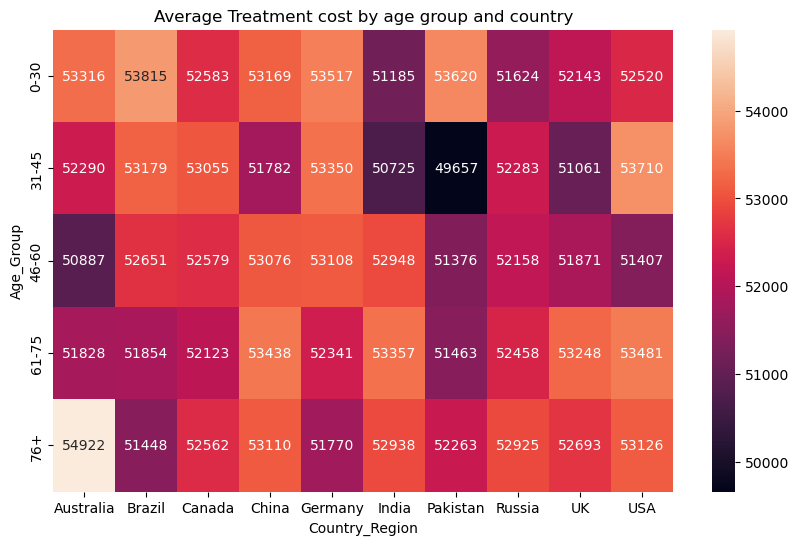

In [158]:
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data,annot=True,fmt='.0f')
plt.title("Average Treatment cost by age group and country")
plt.show()

# Assess weather higher treatment cost is associated with longer survival 

In [163]:
from scipy.stats import pearsonr, spearmanr
x=data["Treatment_Cost_USD"]
y=data["Survival_Years"]

# Perform pearson correlation test
pearson_corr,pearson_p = pearsonr(x,y)
print(f"Pearson Correlation Coefficient:{pearson_corr}")
print(f"Pearson p value:{pearson_p}")

#Perform spearman correlation test
spearman_corr,spearman_p = spearmanr(x,y)
print(f"spearman Correlation Coefficient:{spearman_corr}")
print(f"spearman p value:{spearman_p}")

alpha = 0.05
def interpret_corr(corr,p,method):
    if p<alpha:
        print(f"{method} ,we reject the null hypothesis")
    else:
        print(f"{method},we failed to reject null hypothesis")

interpret_corr(pearson_corr,pearson_p,"pearson")
interpret_corr(spearman_corr,spearman_p,"spearman")



Pearson Correlation Coefficient:-0.00042940542830214955
Pearson p value:0.9235082012963307
spearman Correlation Coefficient:-0.0004454737292549569
spearman p value:0.9206551702014918
pearson,we failed to reject null hypothesis
spearman,we failed to reject null hypothesis


<Axes: xlabel='Treatment_Cost_USD', ylabel='Survival_Years'>

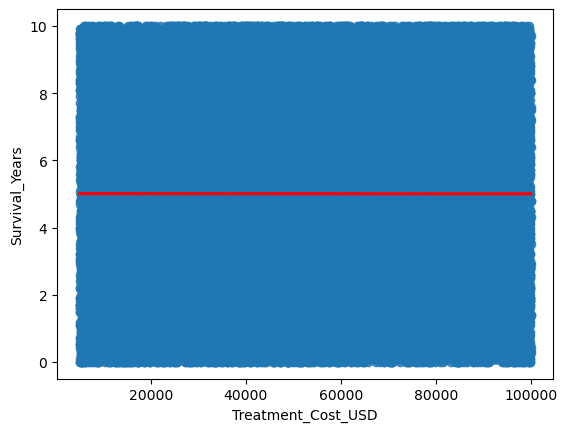

In [165]:
sns.regplot(x=x,y=y,line_kws={"color":"red"})

# Evaluate if higher cancer stages lead to greater treatment costs and reduced survival years

In [167]:
df=data.copy()

In [168]:
df

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score,Age_Group
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92,61-75
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65,31-45
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84,76+
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12,31-45
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62,31-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63,76+
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03,31-45
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02,61-75
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54,0-30


In [169]:
stage_order=["Stage 0","Stage I","Stage II","Stage III","Stage IV"]

In [173]:
grouped_stats=df.groupby("Cancer_Stage")[["Treatment_Cost_USD","Survival_Years"]].mean().reset_index()

In [174]:
grouped_stats

,Cancer_Stage,Treatment_Cost_USD,Survival_Years
0,Stage 0,52572.589493,5.015199
1,Stage I,52674.079638,5.012990
2,Stage II,52082.841258,4.995170
3,Stage III,52708.197506,5.036311
4,Stage IV,52302.471041,4.972596


In [176]:
grouped_costs=[]
grouped_survival=[]

for stage in stage_order:
    stage_data=df[df["Cancer_Stage"]==stage]
    cost=stage_data["Treatment_Cost_USD"]
    survival=stage_data["Survival_Years"]
    grouped_costs.append(cost)
    grouped_survival.append(survival)

In [177]:
grouped_costs

[1        12573.41
 6         9790.83
 17       56875.63
 22       89075.81
 29       32889.23
            ...   
 49988    52763.24
 49989    30400.57
 49995    71463.70
 49997     5338.25
 49999    64023.82
 Name: Treatment_Cost_USD, Length: 9889, dtype: float64,
 3        67446.25
 7        17161.40
 10       15093.39
 11       72315.19
 19       40131.04
            ...   
 49979     9090.63
 49981    94507.13
 49987    51598.72
 49993    75193.19
 49996    49619.66
 Name: Treatment_Cost_USD, Length: 10046, dtype: float64,
 2         6984.33
 8        56458.48
 9        56133.45
 12       99120.52
 13       94210.93
            ...   
 49973    58707.61
 49978    88123.42
 49990    38290.91
 49991    73592.91
 49992    99623.46
 Name: Treatment_Cost_USD, Length: 10124, dtype: float64,
 0        62913.44
 4        77977.12
 16       59285.13
 28       97036.73
 31       65719.90
            ...   
 49968    46434.35
 49976    52551.96
 49980    72094.76
 49983    47086.44
 49994    

In [179]:
from scipy.stats import shapiro, f_oneway
normal_cost=0
normal_survival=0


for i in range(len(stage_order)):
    cost_p=shapiro(grouped_costs[i]).pvalue
    surv_p=shapiro(grouped_survival[i]).pvalue
    print(f"cost {cost_p} for group{i}")
    print(f"survival {surv_p}  for group{i}")
    if cost_p<0.05:
        normal_cost+=1
    if surv_p<0.05:
        normal_survival+=1
    

    

cost 1.5471821061637387e-47 for group0
survival 1.6291039522109283e-47  for group0
cost 7.306523956944908e-48 for group1
survival 7.575551046261213e-48  for group1
cost 8.943579643047347e-48 for group2
survival 4.041659465829021e-48  for group2
cost 5.267270033024548e-48 for group3
survival 1.3648520457950436e-47  for group3
cost 1.5838640189581322e-47 for group4
survival 2.2992598289842037e-47  for group4


In [182]:
print(normal_cost)
print(normal_survival)

5
5


In [184]:
from scipy.stats import kruskal

kruskal_cost=kruskal(*grouped_costs)
kruskal_survival=kruskal(*grouped_survival)


p_cost=kruskal_cost.pvalue
p_survival=kruskal_survival.pvalue

In [185]:
print(p_cost)
print(p_survival)

0.4254451689062656
0.6033078729984223


# Examin whether higher genetic risk ampllifies the negetive effects of smoking on cancer serverity and survival outcomes

In [193]:
import statsmodels.formula.api as smf

model = smf.ols("Target_Severity_Score ~ Genetic_Risk*Smoking",data=data).fit()
model.summary2().tables[1].loc["Genetic_Risk:Smoking"]

Coef.      -0.000228
Std.Err.    0.000471
t          -0.484187
P>|t|       0.628255
[0.025     -0.001150
0.975]      0.000694
Name: Genetic_Risk:Smoking, dtype: float64

In [194]:
p_value=0.628255

Interpretation:
The interaction coefficient is negative but very small: -0.030228
The p-value = 0.628, which is greater than 0.05, so we fail to reject the null hypothesis.
Conclusion (Statistical):
Test Used: Multiple Linear Regression with interaction term

Null Hypothesis (H₀):
No interaction effect between genetic risk and smoking
Alternative Hypothesis (H₁):
There is an interaction effect.
    
The interaction effect between Genetic Risk and Smoking on Target Severity Score is not statistically significant (p = 0.628 > 0.05).
This means that based on your data, there is no evidence that Genetic Risk amplifies or reduces the effect of Smoking on the Target Severity Score.
In other words, smoking and genetic risk may each have independent effects (or none), but they do not interact in a way that significantly changes the outcome.